In [ ]:
import glob
import os
import time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.interpolate import interp1d
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, accuracy_score,
                             matthews_corrcoef)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.models import Model

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

RESULT_DIR = '../content/drive/MyDrive/REV_2025/Results/'
DATA_DIR = '../content/drive/MyDrive/REV_2025/Dataset'
SAMPLING_RATE = 25
WINDOW_DURATION = 2.6
STEP_DURATION = 1.0

WINDOW_SIZE = int(WINDOW_DURATION * SAMPLING_RATE)
STEP_SIZE = int(STEP_DURATION * SAMPLING_RATE)

FEATURE_COLS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
NUM_FEATURES = len(FEATURE_COLS)

LABEL_MAP = {
    'fall': 'fall',
    'walk': 'non-fall',
    'run': 'non-fall',
    'static': 'non-fall'
}


TEST_SIZE = 0.2
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001

ENABLE_AUGMENTATION = True
AUGMENT_RATIO = 2

In [ ]:
class FallDataAugmentor:
    """
    Data augmentation cho fall detection
    Technic:
    1. Jittering - thêm noise nhỏ
    2. Scaling - scale amplitude
    3. Rotation - rotate trong không gian 3D (gyro)
    4. Permutation - shuffle timesteps nhỏ
    5. Magnitude warp - thay đổi shape của signal
    6. Window slicing - crop + pad
    """

    def __init__(self, seed=42):
        np.random.seed(seed)

    @staticmethod
    def jittering(X, sigma=0.03):
        """Thêm Gaussian noise nhỏ"""
        noise = np.random.normal(0, sigma, X.shape)
        return X + noise

    @staticmethod
    def scaling(X, sigma=0.1):
        """Scale từng feature với hệ số ngẫu nhiên"""
        scale_factor = np.random.normal(1.0, sigma, size=X.shape[1])
        return X * scale_factor

    @staticmethod
    def rotation(X):
        """Rotate 3D acceleration và gyroscope vectors"""
        X_aug = X.copy()
        theta = np.random.uniform(0, 2 * np.pi)
        cos_t = np.cos(theta)
        sin_t = np.sin(theta)

        # Rotate accel (indices 0,1,2)
        ax_new = X_aug[:, 0] * cos_t - X_aug[:, 1] * sin_t
        ay_new = X_aug[:, 0] * sin_t + X_aug[:, 1] * cos_t
        X_aug[:, 0] = ax_new
        X_aug[:, 1] = ay_new

        # Rotate gyro (indices 3,4,5)
        gx_new = X_aug[:, 3] * cos_t - X_aug[:, 4] * sin_t
        gy_new = X_aug[:, 3] * sin_t + X_aug[:, 4] * cos_t
        X_aug[:, 3] = gx_new
        X_aug[:, 4] = gy_new

        return X_aug

    @staticmethod
    def permutation(X, max_segments=4):
        """Shuffle segment nhỏ của time series"""
        X_aug = X.copy()
        num_seg = np.random.randint(1, max_segments)
        seg_size = len(X) // num_seg

        for i in range(num_seg):
            start = i * seg_size
            end = start + seg_size if i < num_seg - 1 else len(X)
            seg = X_aug[start:end].copy()
            shift = np.random.randint(-2, 3)
            if shift != 0:
                X_aug[start:end] = np.roll(seg, shift, axis=0)

        return X_aug

    @staticmethod
    def magnitude_warp(X, sigma=0.2, knot=4):
        """Warp magnitude của signal bằng cubic spline"""
        X_aug = X.copy()
        time_steps = np.linspace(0, 1, X.shape[0])

        for col in range(X.shape[1]):
            knot_pos = np.sort(np.random.uniform(0, 1, knot))
            knot_vals = np.random.normal(1.0, sigma, knot)
            knot_pos = np.concatenate([[0], knot_pos, [1]])
            knot_vals = np.concatenate([[1.0], knot_vals, [1.0]])

            f = interp1d(knot_pos, knot_vals, kind='cubic')
            warp_function = f(time_steps)
            X_aug[:, col] = X_aug[:, col] * np.clip(warp_function, 0.5, 1.5)

        return X_aug

    @staticmethod
    def window_slicing(X, reduce_ratio=0.9):
        """Crop + pad window"""
        X_aug = X.copy()
        crop_len = int(len(X) * reduce_ratio)
        start = np.random.randint(0, len(X) - crop_len + 1)
        end = start + crop_len
        cropped = X[start:end]

        if np.random.random() > 0.5:
            # Reflection padding
            pad_len = len(X) - len(cropped)
            pad_before = pad_len // 2
            pad_after = pad_len - pad_before
            X_aug = np.vstack([cropped[:pad_before][::-1],
                               cropped,
                               cropped[-pad_after:][::-1]])
        else:
            # Zero padding
            pad_len = len(X) - len(cropped)
            pad_before = pad_len // 2
            pad_after = pad_len - pad_before
            X_aug = np.vstack([np.zeros((pad_before, X.shape[1])),
                               cropped,
                               np.zeros((pad_after, X.shape[1]))])

        return X_aug[:len(X)]

    @staticmethod
    def window_warping(X, window_ratio=0.5, warping_ratio=1.1):
        """Stretch/squeeze một window nhỏ"""
        X_aug = X.copy()
        window_size = int(len(X) * window_ratio)
        window_start = np.random.randint(0, len(X) - window_size + 1)
        window_end = window_start + window_size
        warp_factor = np.random.uniform(1.0 / warping_ratio, warping_ratio)

        for col in range(X.shape[1]):
            warped_size = int(window_size * warp_factor)
            if warped_size > 0:
                window_data = X[window_start:window_end, col]
                warped_indices = np.linspace(0, window_size - 1, warped_size)
                f = interp1d(np.arange(window_size), window_data,
                             kind='linear', fill_value='extrapolate')
                warped_window = f(warped_indices)

                if warped_size <= window_size:
                    X_aug[window_start:window_start + warped_size, col] = warped_window
                else:
                    f_back = interp1d(np.arange(warped_size), warped_window,
                                      kind='linear', fill_value='extrapolate')
                    X_aug[window_start:window_end, col] = f_back(
                        np.linspace(0, warped_size - 1, window_size))


        @staticmethod
        def static_rotation(X, max_angle=15):
            """
            Tăng cường dữ liệu static bằng cách rotate accelerometer
            (mô phỏng các tư thế ngồi/ngồi khác nhau)
            max_angle: độ lệch góc tối đa (±15 độ)
            """
            X_aug = X.copy()

            # Random góc nghiêng cho từng trục
            roll_angle = np.deg2rad(np.random.uniform(-max_angle, max_angle))  # Roll
            pitch_angle = np.deg2rad(np.random.uniform(-max_angle, max_angle))  # Pitch
            yaw_angle = np.deg2rad(np.random.uniform(-max_angle / 2, max_angle / 2))  # Yaw (nhỏ hơn)

            # Rotation matrices cho từng góc
            cos_roll, sin_roll = np.cos(roll_angle), np.sin(roll_angle)
            cos_pitch, sin_pitch = np.cos(pitch_angle), np.sin(pitch_angle)
            cos_yaw, sin_yaw = np.cos(yaw_angle), np.sin(yaw_angle)

            # Rotate accelerometer (indices 0,1,2: ax, ay, az)
            ax, ay, az = X_aug[:, 0], X_aug[:, 1], X_aug[:, 2]

            # Roll rotation (X-Z plane)
            ax_roll = ax * cos_roll + az * sin_roll
            az_roll = -ax * sin_roll + az * cos_roll

            # Pitch rotation (Y-Z plane)
            ay_pitch = ay * cos_pitch - az_roll * sin_pitch
            az_pitch = ay * sin_pitch + az_roll * cos_pitch

            # Yaw rotation (X-Y plane)
            ax_final = ax_roll * cos_yaw - ay_pitch * sin_yaw
            ay_final = ax_roll * sin_yaw + ay_pitch * cos_yaw

            X_aug[:, 0] = ax_final
            X_aug[:, 1] = ay_final
            X_aug[:, 2] = az_pitch

            # Thêm noise nhỏ cho gyroscope (mô phỏng rung nhẹ khi static)
            gyro_noise = np.random.normal(0, 0.02, X.shape[1:])  # Noise rất nhỏ
            X_aug[:, 3:] += gyro_noise

            return X_aug


        @staticmethod
        def static_tilt_variation(X, tilt_strength=0.1):
            """
            Biến đổi tilt nhẹ cho static (ngồi nghiêng, đứng lệch)
            """
            X_aug = X.copy()

            # Tạo tilt vector ngẫu nhiên cho accel
            tilt_vector = np.random.normal(0, tilt_strength, 3)  # Chỉ 3 trục accel

            # Áp dụng tilt lên toàn bộ window
            X_aug[:, :3] += tilt_vector

            # Normalize gravity vector (~1g)
            gravity_norm = np.linalg.norm(X_aug[:, :3], axis=1, keepdims=True)
            X_aug[:, :3] = X_aug[:, :3] / np.clip(gravity_norm, 0.5, 2.0)

            return X_aug

        return X_aug

    def augment(self, X, method='random', **kwargs):
        """Apply augmentation method"""
        if method == 'jittering':
            return self.jittering(X, **kwargs)
        elif method == 'scaling':
            return self.scaling(X, **kwargs)
        elif method == 'rotation':
            return self.rotation(X)
        elif method == 'permutation':
            return self.permutation(X, **kwargs)
        elif method == 'magnitude_warp':
            return self.magnitude_warp(X, **kwargs)
        elif method == 'window_slicing':
            return self.window_slicing(X, **kwargs)
        elif method == 'window_warping':
            return self.window_warping(X, **kwargs)
        elif method == 'random':
            methods = ['jittering', 'scaling', 'rotation', 'permutation',
                       'magnitude_warp', 'window_slicing', 'window_warping']
            chosen = np.random.choice(methods)
            return self.augment(X, method=chosen, **kwargs)
        else:
            raise ValueError(f"Unknown method: {method}")


def augment_training_data(X_train, y_train, target_classes=['fall', 'static'], augment_ratio=4, seed=42):
    """
    Augment cả fall VÀ static class
    """
    np.random.seed(seed)
    augmentor = FallDataAugmentor(seed=seed)

    X_augmented = []
    y_augmented = []

    aug_methods_fall = [
        ('jittering', {'sigma': 0.03}),
        ('scaling', {'sigma': 0.1}),
        ('rotation', {}),
        ('permutation', {'max_segments': 4}),
        ('magnitude_warp', {'sigma': 0.2, 'knot': 4}),
    ]

    aug_methods_static = [
        ('static_rotation', {'max_angle': 15}),
        ('static_tilt_variation', {'tilt_strength': 0.08}),
        ('jittering', {'sigma': 0.01}),
        ('scaling', {'sigma': 0.05}),
        ('window_slicing', {'reduce_ratio': 0.95})
    ]

    print(f"\n" + "=" * 70)
    print(f"DATA AUGMENTATION FOR {target_classes}")
    print("=" * 70)

    total_original = len(X_train)

    for target_class in target_classes:
        target_indices = np.where(y_train == target_class)[0]
        n_target = len(target_indices)

        if n_target == 0:
            print(f"⚠ No '{target_class}' samples found!")
            continue

        print(f"Augmenting '{target_class}': {n_target} → {int(n_target * augment_ratio)}")

        if target_class == 'static':
            methods = aug_methods_static
        else:
            methods = aug_methods_fall

        n_to_generate = int(n_target * (augment_ratio - 1))

        for i in range(n_to_generate):
            idx = np.random.choice(target_indices)
            X_sample = X_train[idx]

            method, params = methods[np.random.randint(0, len(methods))]
            X_aug = augmentor.augment(X_sample, method=method, **params)

            X_augmented.append(X_aug)
            y_augmented.append(target_class)

    # Combine original + augmented
    if X_augmented:
        X_combined = np.vstack([X_train, np.array(X_augmented)])
        y_combined = np.concatenate([y_train, np.array(y_augmented)])

        # Shuffle
        perm = np.random.permutation(len(X_combined))
        X_combined = X_combined[perm]
        y_combined = y_combined[perm]

        print(f"\nAugmentation completed!")
        print(f"Total dataset: {len(X_train)} → {len(X_combined)}")

        unique, counts = np.unique(y_combined, return_counts=True)
        for label, count in zip(unique, counts):
            pct = (count / len(y_combined)) * 100
            print(f"  {label:10s}: {count:6d} ({pct:5.1f}%)")

        return X_combined, y_combined

    return X_train, y_train

In [ ]:
def load_activity_folder(activity_folder, label_name, window_size, step_size):
    csv_files = sorted(glob.glob(os.path.join(activity_folder, '*.csv')))
    if len(csv_files) == 0:
        return np.array([]), np.array([])

    print(f"  Loading {len(csv_files)} files from {os.path.basename(activity_folder)}/")
    all_windows_x = []
    all_windows_y = []

    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file)
            missing_cols = [col for col in FEATURE_COLS if col not in df.columns]
            if missing_cols:
                print(f"    Skipping {os.path.basename(csv_file)}: missing {missing_cols}")
                continue

            data_x = df[FEATURE_COLS].values.astype(np.float32)
            if len(data_x) < window_size:
                print(f"    Skipping {os.path.basename(csv_file)}: only {len(data_x)} samples (need {window_size})")
                continue

            for i in range(0, len(data_x) - window_size + 1, step_size):
                window_x = data_x[i:i + window_size]
                all_windows_x.append(window_x)
                all_windows_y.append(label_name)

            print(
                f"     {os.path.basename(csv_file)}: {len(data_x)} samples → {len(range(0, len(data_x) - window_size + 1, step_size))} windows")
        except Exception as e:
            print(f"     Error loading {os.path.basename(csv_file)}: {e}")
            continue

    if len(all_windows_x) == 0:
        return np.array([]), np.array([])
    return np.array(all_windows_x), np.array(all_windows_y)


def load_all_activities(base_dir, window_size, step_size):
    print("\n" + "=" * 70)
    print("LOADING DATA FROM FOLDERS")
    print("=" * 70)

    all_X = []
    all_y = []

    for activity_folder, label in LABEL_MAP.items():
        activity_path = os.path.join(base_dir, activity_folder)
        if not os.path.exists(activity_path):
            print(f"  ⚠ Folder not found: {activity_path}")
            continue

        X, y = load_activity_folder(activity_path, label, window_size, step_size)
        if len(X) > 0:
            all_X.append(X)
            all_y.append(y)
            print(f"  → {activity_folder}: {len(X)} windows (label: {label})")

    if len(all_X) == 0:
        raise ValueError("No data loaded! Check folder structure and files.")

    X = np.concatenate(all_X)
    y = np.concatenate(all_y)

    print("\n" + "=" * 70)
    print("DATA SUMMARY (BEFORE AUGMENTATION)")
    print("=" * 70)
    print(f"Total windows: {len(X)}")
    print(f"Window shape:  {X.shape}")

    unique_labels, counts = np.unique(y, return_counts=True)
    for label, count in zip(unique_labels, counts):
        percentage = (count / len(y)) * 100
        print(f"  {label:15s}: {count:6d} windows ({percentage:5.1f}%)")

    min_count = counts.min()
    max_count = counts.max()
    imbalance_ratio = max_count / min_count
    print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1")
    if imbalance_ratio > 3:
        print("High class imbalance! Data augmentation recommended.")

    return X, y

In [ ]:
def preprocess_data(X_train, X_test):
    print("\n" + "=" * 70)
    print("PREPROCESSING")
    print("=" * 70)

    n_samples_train, n_timesteps, n_features = X_train.shape
    n_samples_test = X_test.shape[0]

    X_train_flat = X_train.reshape(-1, n_features)
    X_test_flat = X_test.reshape(-1, n_features)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled = scaler.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(n_samples_train, n_timesteps, n_features)
    X_test_scaled = X_test_scaled.reshape(n_samples_test, n_timesteps, n_features)

    print(f"Scaler fitted on {X_train_flat.shape[0]} samples")
    print(f"Mean: {scaler.mean_}")
    print(f"Std:  {scaler.scale_}")

    joblib.dump(scaler, os.path.join(RESULT_DIR, 'scaler_25hz.pkl'))
    print("Saved scaler file")

    return X_train_scaled, X_test_scaled, scaler

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv1D(24, 5, activation='relu', padding='same')(inputs)
    x = Dropout(0.3)(x)

    x = Conv1D(32, 5, activation='relu', padding='same')(x)
    x = Dropout(0.3)(x)

    # x = Conv1D(32, 5, activation='relu', padding='same')(x)
    # x = Dropout(0.3)(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(0.4)(x)

    x = Dense(16, activation='relu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=inputs, outputs=outputs)

In [ ]:
def train_model(X_train, y_train, X_test, y_test):
    print("\n" + "=" * 70)
    print("MODEL TRAINING")
    print("=" * 70)

    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)

    num_classes = len(label_encoder.classes_)
    print(f"Classes: {label_encoder.classes_}")
    print(f"Num classes: {num_classes}")

    y_train_onehot = tf.keras.utils.to_categorical(y_train_encoded, num_classes)
    y_test_onehot = tf.keras.utils.to_categorical(y_test_encoded, num_classes)

    input_shape = (X_train.shape[1], X_train.shape[2])
    model = build_model(input_shape, num_classes)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    from sklearn.utils.class_weight import compute_class_weight
    class_weights_values = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_encoded),
        y=y_train_encoded
    )
    class_weights = {i: weight for i, weight in enumerate(class_weights_values)}
    print(f"\nClass weights: {class_weights}")

    callbacks = [
        ModelCheckpoint(
            RESULT_DIR + 'best_model_25hz.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        X_train, y_train_onehot,
        validation_data=(X_test, y_test_onehot),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    return model, history, label_encoder

In [ ]:
def plot_training_history(history, output_file= RESULT_DIR + 'training_history_25hz.png'):
    print("\n" + "=" * 70)
    print("PLOTTING TRAINING HISTORY")
    print("=" * 70)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Training History - 25Hz Fall Detection Model',
                 fontsize=16, fontweight='bold')

    ax1.plot(history.history['accuracy'], label='Train Accuracy',
             linewidth=2, marker='o', markersize=4)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy',
             linewidth=2, marker='s', markersize=4)
    ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.05])

    best_val_acc = max(history.history['val_accuracy'])
    best_epoch = history.history['val_accuracy'].index(best_val_acc)
    ax1.annotate(f'Best: {best_val_acc:.4f}',
                 xy=(best_epoch, best_val_acc),
                 xytext=(best_epoch + 1, best_val_acc - 0.05),
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                 fontsize=9)

    ax2.plot(history.history['loss'], label='Train Loss',
             linewidth=2, marker='o', markersize=4)
    ax2.plot(history.history['val_loss'], label='Val Loss',
             linewidth=2, marker='s', markersize=4)
    ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right', fontsize=10)
    ax2.grid(True, alpha=0.3)

    best_val_loss = min(history.history['val_loss'])
    best_epoch_loss = history.history['val_loss'].index(best_val_loss)
    ax2.annotate(f'Best: {best_val_loss:.4f}',
                 xy=(best_epoch_loss, best_val_loss),
                 xytext=(best_epoch_loss + 1, best_val_loss + 0.05),
                 bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8),
                 fontsize=9)

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f" Saved training history: {output_file}")

    print("\nTraining Summary:")
    print(f"  Final train accuracy:     {history.history['accuracy'][-1]:.4f}")
    print(f"  Final val accuracy:       {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Best val accuracy:        {best_val_acc:.4f} (epoch {best_epoch + 1})")
    print(f"  Final train loss:         {history.history['loss'][-1]:.4f}")
    print(f"  Final val loss:           {history.history['val_loss'][-1]:.4f}")
    print(f"  Best val loss:            {best_val_loss:.4f} (epoch {best_epoch_loss + 1})")

    return fig

In [ ]:
def evaluate_model_comprehensive(model, X_test, y_test, label_encoder):
    """Comprehensive model evaluation"""
    print("\n" + "=" * 70)
    print("COMPREHENSIVE MODEL EVALUATION")
    print("=" * 70)

    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    y_test_encoded = label_encoder.transform(y_test)
    y_pred_labels = label_encoder.inverse_transform(y_pred)

    # ========== 1. OVERALL METRICS ==========
    print("\n" + "=" * 70)
    print("1. OVERALL PERFORMANCE")
    print("=" * 70)

    overall_accuracy = accuracy_score(y_test, y_pred_labels)
    print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy * 100:.2f}%)")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_labels, target_names=label_encoder.classes_))

    # ========== 2. CONFUSION MATRIX ==========
    print("\n" + "=" * 70)
    print("2. CONFUSION MATRIX")
    print("=" * 70)

    # --- Compute confusion matrix (count) ---
    cm = confusion_matrix(y_test, y_pred_labels, labels=label_encoder.classes_)

    # --- Save COUNT confusion matrix ---
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_encoder.classes_)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title('Confusion Matrix - 25Hz Model')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, 'confusion_matrix_25hz.png'), dpi=300)
    plt.close()
    print("Saved confusion matrix (count only, not displayed)")

    # --- Normalize confusion matrix (row-wise) ---
    cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)
    cm_normalized = np.nan_to_num(cm_normalized)

    # --- PRINT normalized confusion matrix ---
    print("\nNormalized Confusion Matrix (%):")
    print(f"{'':15s}", end='')
    for label in label_encoder.classes_:
        print(f"{label:12s}", end='')
    print()

    for i, label in enumerate(label_encoder.classes_):
        print(f"{label:15s}", end='')
        for j in range(len(label_encoder.classes_)):
            print(f"{cm_normalized[i, j]:11.1%}", end='')
        print()

    # --- DISPLAY normalized confusion matrix ONLY ---
    fig, ax = plt.subplots(figsize=(9, 7))

    disp_norm = ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=label_encoder.classes_
    )

    disp_norm.plot(
        ax=ax,
        cmap='YlOrRd',
        values_format='.1%',
        xticks_rotation=45
    )

    ax.set_title('Normalized Confusion Matrix (Row-wise %)',
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    plt.tight_layout()
    plt.savefig(os.path.join(
        RESULT_DIR,
        'confusion_matrix_normalized_25hz.png'
    ), dpi=300, bbox_inches='tight')
    plt.show()

    # ========== 3. BINARY FALL DETECTION METRICS ==========
    if 'fall' in label_encoder.classes_:
        print("\n" + "=" * 70)
        print("3. FALL DETECTION METRICS (Binary Classification)")
        print("=" * 70)

        fall_idx = np.where(label_encoder.classes_ == 'fall')[0][0]
        y_test_binary = (y_test_encoded == fall_idx).astype(int)
        y_pred_binary = (y_pred == fall_idx).astype(int)

        precision = precision_score(y_test_binary, y_pred_binary)
        recall = recall_score(y_test_binary, y_pred_binary)
        f1 = f1_score(y_test_binary, y_pred_binary)

        print(f"Precision:     {precision:.4f} ({precision * 100:.2f}%)")
        print(f"Recall:        {recall:.4f} ({recall * 100:.2f}%)")
        print(f"F1-Score:      {f1:.4f}")

        tn = cm[1, 1] if cm.shape[0] > 1 else 0
        fp = cm[1, 0] if cm.shape[0] > 1 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        print(f"Specificity:   {specificity:.4f} ({specificity * 100:.2f}%)")

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        print(f"False Pos Rate: {fpr:.4f} ({fpr * 100:.2f}%)")

        fn = cm[0, 1] if cm.shape[0] > 1 else 0
        fnr = fn / (fn + cm[0, 0]) if (fn + cm[0, 0]) > 0 else 0
        print(f"False Neg Rate: {fnr:.4f} ({fnr * 100:.2f}%)")

        mcc = matthews_corrcoef(y_test_binary, y_pred_binary)
        print(f"Matthews Corr:  {mcc:.4f}")

        # ========== 5. SAFETY ASSESSMENT ==========
        print("\n" + "=" * 70)
        print("5. SAFETY ASSESSMENT FOR FALL DETECTION")
        print("=" * 70)

        if recall >= 0.95:
            print(f" EXCELLENT: Recall = {recall:.4f} ≥ 0.95")
            print("   → Model detects 95%+ of falls (very safe)")
        elif recall >= 0.90:
            print(f" GOOD: Recall = {recall:.4f} ≥ 0.90")
            print("   → Model detects 90%+ of falls (acceptable)")
        elif recall >= 0.80:
            print(f" FAIR: Recall = {recall:.4f} ≥ 0.80")
            print("   → Model misses 20%+ falls (needs improvement)")
        else:
            print(f" POOR: Recall = {recall:.4f} < 0.80")
            print("   → Model misses too many falls (DANGEROUS!)")

        return {
            'accuracy': overall_accuracy,
            'precision': precision,
            'recall': recall,
            'specificity': specificity,
            'f1': f1,
            'fpr': fpr,
            'fnr': fnr,
            'mcc': mcc
        }

In [ ]:
def convert_to_tflite(model, X_test):
    print("\n" + "=" * 70)
    print("TFLITE CONVERSION")
    print("=" * 70)

    def representative_dataset():
        for i in range(min(100, len(X_test))):
            yield [X_test[i:i + 1].astype(np.float32)]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.float32
    converter.inference_output_type = tf.float32

    tflite_model = converter.convert()

    with open(RESULT_DIR + 'model_25hz.tflite', 'wb') as f:
        f.write(tflite_model)

    model_size = len(tflite_model) / 1024
    print(f" Saved TFLite model: model_25hz.tflite ({model_size:.2f} KB)")

    with open(RESULT_DIR + 'model_25hz.h', 'w') as f:
        f.write('#ifndef MODEL_25HZ_H\n')
        f.write('#define MODEL_25HZ_H\n\n')
        f.write('const unsigned char model_25hz_tflite[] = {\n  ')
        hex_array = ', '.join([f'0x{b:02x}' for b in tflite_model])
        hex_lines = [hex_array[i:i + 47] for i in range(0, len(hex_array), 48)]
        f.write('\n  '.join(hex_lines))
        f.write('\n};\n')
        f.write(f'const unsigned int model_25hz_tflite_len = {len(tflite_model)};\n\n')
        f.write('#endif\n')

    print(f" Saved C header: model_25hz.h")
    return tflite_model

In [ ]:
def main():
    start_time = time.time()

    # Ensure the result directory exists
    os.makedirs(RESULT_DIR, exist_ok=True)

    X, y = load_all_activities(DATA_DIR, WINDOW_SIZE, STEP_SIZE)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
    )

    print(f"\nTrain set (before augment): {len(X_train)} windows")
    print(f"Test set:                  {len(X_test)} windows")

    if ENABLE_AUGMENTATION:
        X_train, y_train = augment_training_data(
            X_train, y_train,
            target_classes=['fall'],
            # target_classes=['fall', 'static'],
            augment_ratio=AUGMENT_RATIO,
            seed=RANDOM_SEED
        )

    print(f"\nFinal train set (after augment): {len(X_train)} windows")
    print(f"Test set:                       {len(X_test)} windows")

    # Preprocess
    X_train_scaled, X_test_scaled, scaler = preprocess_data(X_train, X_test)

    # Train
    model, history, label_encoder = train_model(
        X_train_scaled, y_train, X_test_scaled, y_test
    )

    # Convert and save TFLite model and C header
    tflite_model = convert_to_tflite(model, X_test_scaled)

    # Save label encoder
    joblib.dump(label_encoder, os.path.join(RESULT_DIR, 'label_encoder_25hz.pkl'))

    plot_training_history(history, os.path.join(RESULT_DIR, 'training_history_25Hz.png'))
    evaluate_model_comprehensive(model, X_test_scaled, y_test, label_encoder)

    elapsed_time = time.time() - start_time
    print(f"\n{'=' * 70}")
    print(f"TRAINING COMPLETED IN {elapsed_time:.1f}s")
    print(f"{'=' * 70}")

    print("\nGenerated files:")
    print("  - best_model_25hz.h5           (Keras model)")
    print("  - model_25hz.tflite            (TFLite quantized)")
    print("  - model_25hz.h                 (C header for ESP32)")
    print("  - scaler_25hz.pkl              (StandardScaler)")
    print("  - label_encoder_25hz.pkl       (Label encoder)")
    print("  - confusion_matrix_25hz.png    (Confusion matrix)")
    print("  - training_history_25hz.png    (Training curves)")


LOADING DATA FROM FOLDERS
  Loading 34 files from fall/
     imu_fall_1.csv: 2613 samples → 102 windows
     imu_fall_10.csv: 192 samples → 6 windows
     imu_fall_11.csv: 215 samples → 7 windows
     imu_fall_12.csv: 171 samples → 5 windows
     imu_fall_13.csv: 213 samples → 6 windows
     imu_fall_14.csv: 198 samples → 6 windows
     imu_fall_15.csv: 162 samples → 4 windows
     imu_fall_16.csv: 241 samples → 8 windows
     imu_fall_17.csv: 139 samples → 3 windows
     imu_fall_18.csv: 176 samples → 5 windows
     imu_fall_19.csv: 160 samples → 4 windows
     imu_fall_2.csv: 111 samples → 2 windows
     imu_fall_20.csv: 117 samples → 3 windows
     imu_fall_21.csv: 119 samples → 3 windows
     imu_fall_22.csv: 196 samples → 6 windows
     imu_fall_23.csv: 237 samples → 7 windows
     imu_fall_24.csv: 202 samples → 6 windows
     imu_fall_25.csv: 173 samples → 5 windows
     imu_fall_26.csv: 184 samples → 5 windows
     imu_fall_27.csv: 188 samples → 5 windows
     imu_fall_28.csv: 

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 65, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 65, 24)         │           744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 65, 24)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 65, 32)         │         3,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 65, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,234 (24.35 KB)

 Trainable params: 6,234 (24.35 KB)

...

318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9822 - loss: 0.0509 - val_accuracy: 0.9900 - val_loss: 0.0297 - learning_rate: 5.0000e-04
Epoch 30/100
308/318 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9809 - loss: 0.0671
Epoch 30: val_accuracy did not improve from 0.98996
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0669 - val_accuracy: 0.9859 - val_loss: 0.0383 - learning_rate: 5.0000e-04
Epoch 31/100
314/318 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9814 - loss: 0.0655
Epoch 31: val_accuracy did not improve from 0.98996
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9814 - loss: 0.0655 - val_accuracy: 0.9791 - val_loss: 0.0485 - learning_rate: 5.0000e-04
Epoch 32/100
303/318 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9787 - loss: 0.0644
Epoch 32: val_accuracy did not improve from 0.98996
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9787 - loss: 0.0643 - val_accuracy: 0.9735 - val_loss: 0.0615 - learning_rate: 5.0000e-04


318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9810 - loss: 0.0481 - val_accuracy: 0.9904 - val_loss: 0.0271 - learning_rate: 2.5000e-04
Epoch 42/100
308/318 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9888 - loss: 0.0467
Epoch 42: val_accuracy improved from 0.99037 to 0.99398, saving model to ../content/drive/MyDrive/REV_2025/Results/best_model_25hz.h5


318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0466 - val_accuracy: 0.9940 - val_loss: 0.0204 - learning_rate: 2.5000e-04
Epoch 43/100
316/318 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9906 - loss: 0.0344
Epoch 43: val_accuracy did not improve from 0.99398
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9906 - loss: 0.0344 - val_accuracy: 0.9791 - val_loss: 0.0548 - learning_rate: 2.5000e-04
Epoch 44/100
308/318 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9842 - loss: 0.0437
Epoch 44: val_accuracy did not improve from 0.99398
318/318 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9844 - loss: 0.0434 - val_accuracy: 0.9896 - val_loss: 0.0338 - learning_rate: 2.5000e-04
Epoch 45/100
311/318 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9878 - loss: 0.0481
Epoch 45: val_accuracy did not improve from 0.99398
318/318 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9878 - loss: 0.0481 - val_accuracy: 0.9855 - val_loss: 0.0403 - learning_rate: 2.5000e-04


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


 Saved TFLite model: model_25hz.tflite (14.47 KB)
 Saved C header: model_25hz.h

PLOTTING TRAINING HISTORY
 Saved training history: ../content/drive/MyDrive/REV_2025/Results/training_history_25Hz.png

Training Summary:
  Final train accuracy:     0.9896
  Final val accuracy:       0.9928
  Best val accuracy:        0.9940 (epoch 42)
  Final train loss:         0.0305
  Final val loss:           0.0230
  Best val loss:            0.0204 (epoch 42)

COMPREHENSIVE MODEL EVALUATION

1. OVERALL PERFORMANCE
Overall Accuracy: 0.9940 (99.40%)

Classification Report:
              precision    recall  f1-score   support

        fall       0.77      0.98      0.86        48
    non-fall       1.00      0.99      1.00      2443

    accuracy                           0.99      2491
   macro avg       0.89      0.99      0.93      2491
weighted avg       1.00      0.99      0.99      2491


2. CONFUSION MATRIX (NORMALIZED ONLY)
Saved confusion matrix (count only, not displayed)

Normalized Confus

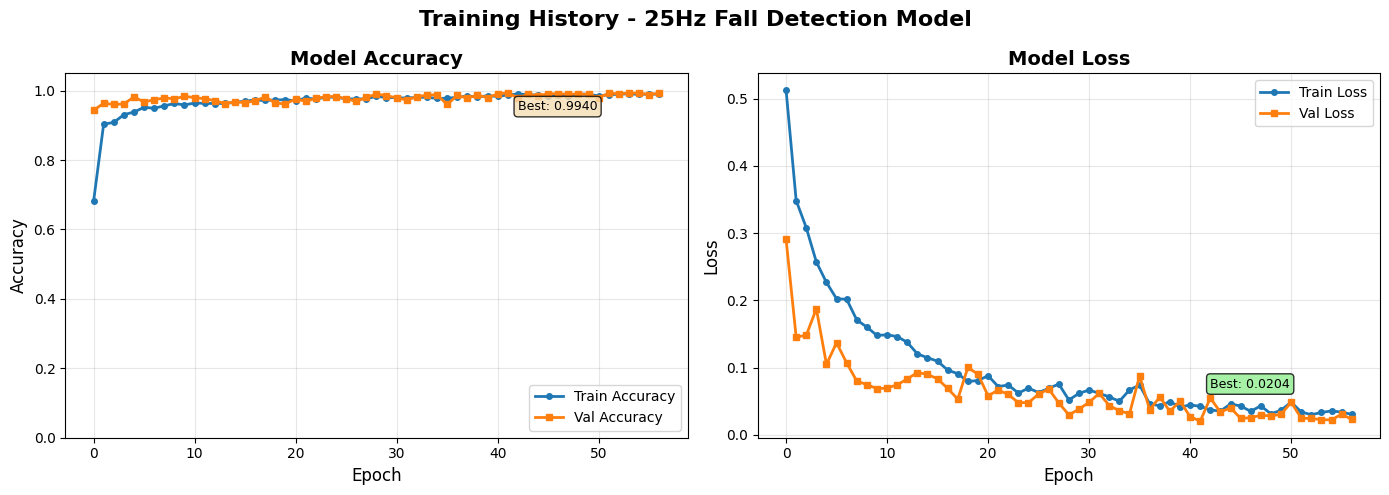

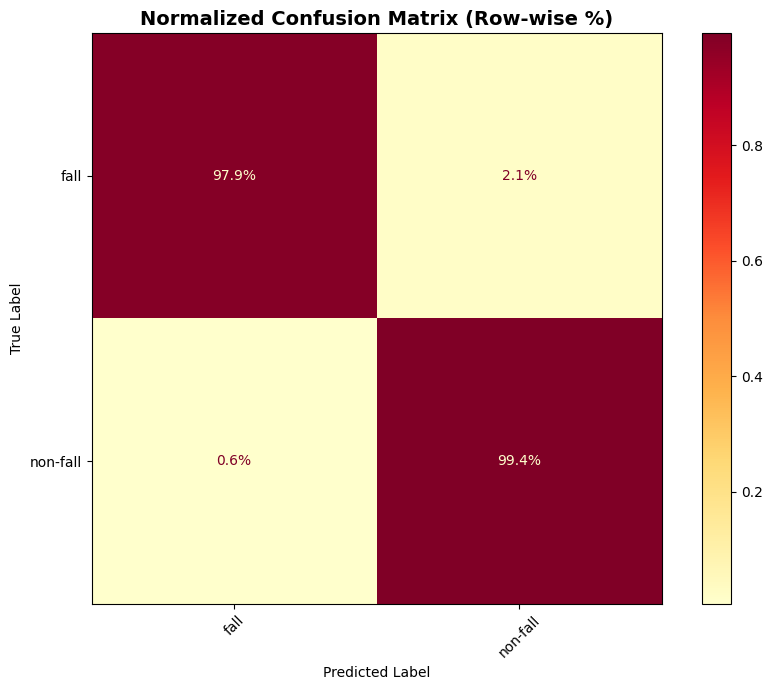


3. FALL DETECTION METRICS (Binary Classification)
Precision:     0.7705 (77.05%)
Recall:        0.9792 (97.92%)
F1-Score:      0.8624
Specificity:   0.9943 (99.43%)
False Pos Rate: 0.0057 (0.57%)
False Neg Rate: 0.0208 (2.08%)
Matthews Corr:  0.8658

5. SAFETY ASSESSMENT FOR FALL DETECTION
 EXCELLENT: Recall = 0.9792 ≥ 0.95
   → Model detects 95%+ of falls (very safe)

TRAINING COMPLETED IN 86.8s

Generated files:
  - best_model_25hz.h5           (Keras model)
  - model_25hz.tflite            (TFLite quantized)
  - model_25hz.h                 (C header for ESP32)
  - scaler_25hz.pkl              (StandardScaler)
  - label_encoder_25hz.pkl       (Label encoder)
  - confusion_matrix_25hz.png    (Confusion matrix)
  - training_history_25hz.png    (Training curves)
SCALER_MEAN: 0.23831283073123816, -0.35571176534866844, 8.70387094035654, -0.0021414455687727143, -0.005353655652682613, -57717790.698576115, 
SCALER_STD: 2.8319234556920927, 4.513268232559784, 3.103829636288323, 0.56022494886

In [ ]:
if __name__ == "__main__":
    main()

    import joblib

    scaler = joblib.load(os.path.join(RESULT_DIR, 'scaler_25hz.pkl'))
    temp = ""
    for i in scaler.mean_:
        temp += str(i) + ", "
    print("SCALER_MEAN: " + temp)

    temp = ""
    for i in scaler.scale_:
        temp += str(i) + ", "
    print("SCALER_STD: " + temp)